<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week5_2_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<딥러닝 파이토치 교과>
2장 p.69~87

###2.4 파이토치 코드 맛보기

1. price(지동차 가격)
2. maint(지동차 유지 비용)
3. doors(자동차 문 개수)
4. persons(수용 인원)
5. lug_capacity(수하물 용량)
6. safety(안전성)
7. output(차 상태): 이 데이터는 unacc(허용 불가능한 수준) 및 acc(허용 가능한 수준) , 양호
(good) 및 매우 좋은(very good, vgood) 중 하나의 값

In [ ]:
# 필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
#구글 드라이브와 연동
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
dataset= pd.read_csv('/content/gdrive/MyDrive/ESSA/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


- 다섯 개의 행이 단어와 숫자로 구성되어있음 -> 임베딩처리필요 : 단어 to 벡터

<Axes: ylabel='count'>

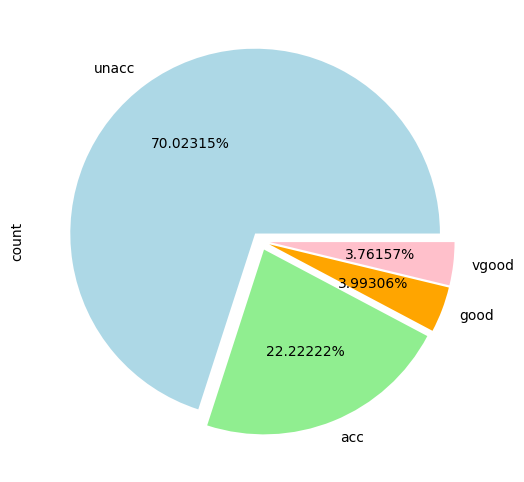

In [ ]:
fig_size= plt.rcParams['figure.figsize']
fig_size[0]=8
fig_size[1]=6
plt.rcParams['figure.figsize']=fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors= ['lightblue','lightgreen','orange','pink'], explode=(0.05,0.05,0.05,0.05))

- 대부분의 자동차는 허용불가능
- 20%만 허용가능
- 이제 전처리 해보자
  - 먼저 단어 to 숫자
  - astype() 이용해서 범주 특성인 데이터 -> 범주형으로 변환 -> 텐서로 변환
> 범주형 데이터 -> dataset[category] -> 넘파이 배열(Numpy array) -> 텐서
  - 범주형 to 숫자(넘파이 배열) : cat.codes 사용
- 넘파이 객체 합치기
    - stack (n차원 배열 합쳐서 n+1차원배열 만듬)
    - concatenate
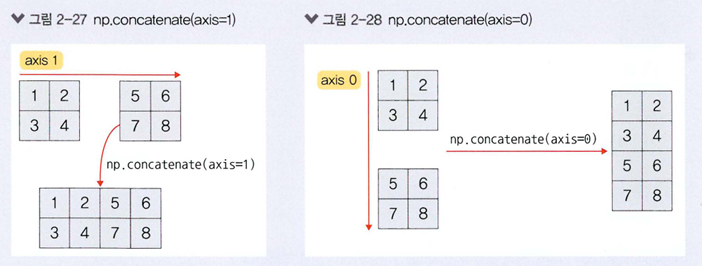

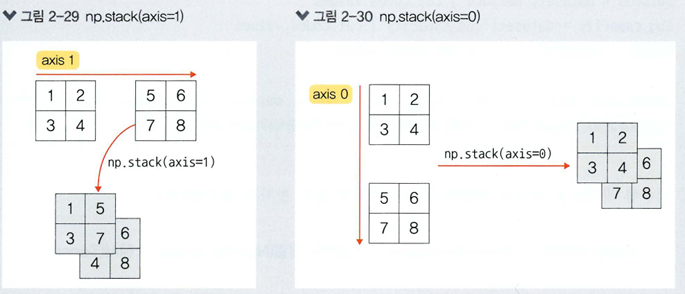


In [ ]:
categorical_columns= ['price','maint','doors','persons','lug_capacity','safety']

for category in categorical_columns:
    # 데이터 to 범주형
    dataset[category]= dataset[category].astype('category')

price= dataset['price'].cat.codes.values
maint= dataset['maint'].cat.codes.values
doors= dataset['doors'].cat.codes.values
persons= dataset['persons'].cat.codes.values
lug_capacity= dataset['lug_capacity'].cat.codes.values
safety= dataset['safety'].cat.codes.values

categorical_data= np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

- 배열 to 텐서

In [ ]:
categorical_data= torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

- 레이블로 사용할 칼럼을 텐서로 변환
- get_dummies : 문자 to 숫자 함수
- ravel(), reshape(), flatten() : 텐서 차원 바꿈

In [ ]:
outputs= pd.get_dummies(dataset.output)
outputs= outputs.values

#1차원 텐서로 변환
outputs= torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


워드 임베딩 : 유사한 단어끼리 유사하게 인코딩되도록 표현
- 높은 차원일수록 세부관계 잘 파악한다.
- 단일 숫자 -> N차원 넘파이 배열로 변경
  1. 범주형 칼럼에 대한 임베딩크기 정의 -> 칼럼 고유값/2

In [ ]:
categorical_column_sizes= [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes ]

# 모든 범주형 칼럼의 고유값 수, 차원 크기
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [ ]:
# 데이터셋 분리
total_records= 1728
test_records= int(total_records * .2)

categorical_train_data= categorical_data[:total_records-test_records]
categorical_test_data= categorical_data[total_records-test_records:total_records]
train_outputs= outputs[:total_records-test_records]
test_outputs= outputs[total_records-test_records:total_records]

In [ ]:
# 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


- 모델 네트워크 생성
1. 클래스로 구현되는 모델은 nn.Module 상속받음
2. __init__() : 모델에서 사용될 파라미터, 신경망 초기화
  - def __ init__(self, embedding_size, output_size, layers, p=0.4)
  - 범주형 칼럼의 임베딩 크기/ 출력층 크기/ 모든 계층에 대한 목록/ 드롭아웃
3. supuer().__init__() : 부모클래스에 접근 시 사용
4. 네트워크 계층 구축하기 위해 for문 이용해 각 계층을 all_layers 목록에 추가
  - Linear : 입력데이터에 선형변환 진행한 결과
  - ReLU
  - BatchNorm1d : 배치정규화
  - Dropout : 과적합방지
5. forward()함수는 학습데이터로 연산진행

In [ ]:
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()
        self.all_embeddings= nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        self.embedding_dropout= nn.Dropout(p)

        all_layers=[]
        num_categorical_cols= sum((nf for ni, nf in embedding_size))

        # 입력층의 크기 찾기 위해 범주형 칼럼 개수를 input_size 변수에 저장
        input_size= num_categorical_cols

        # 4
        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size= i

        all_layers.append(nn.Linear(layers[-1], output_size))

        # 신경망의 모든 계층이 순차적으로 실행되도록 목록을 nn.Sequential클래스로 전달
        self.layers= nn.Sequential(*all_layers)

    def forward(self, x_categorical):
        embeddings= []
        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))

        x= torch.cat(embeddings, 1)
        x= self.embedding_dropout(x)
        x= self.layers(x)
        return x

In [ ]:
# Model 클래스의 객체 생성
# 임베딩 크기, 출력크기, 은닉층 뉴런, 드롭아웃
model= Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


- 모델 훈련 전 손실함수 & 옵티마이저 정의
- 분류-> CE 손실함수사용
- 옵티마이저 -> 아담(Adam)

In [ ]:
# 모델 파라미터 정의
loss_function= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
if torch.cuda.is_available():
    device= torch.device('cuda')
else:
    device= torch.device('cpu')

####**모델학습**

In [ ]:
epochs= 500
aggregated_losses=[]
train_outputs= train_outputs.to(device= device, dtype= torch.int64)

for i in range(epochs):
    i +=1
    y_pred= model(categorical_train_data).to(device)
    single_loss= loss_function(y_pred, train_outputs)

    # 오차 추가
    aggregated_losses.append(single_loss)

    if i%25 ==1:
        print(f'epoch: {i:3} loss: {single_loss.item(): 10.8f}')

    optimizer.zero_grad()
    single_loss.backward()

    # 기울기 없데이트
    optimizer.step()

epoch:   1 loss:  1.64769578
epoch:  26 loss:  1.47265029
epoch:  51 loss:  1.36746883
epoch:  76 loss:  1.26581597
epoch: 101 loss:  1.11045170
epoch: 126 loss:  0.98478347
epoch: 151 loss:  0.85958225
epoch: 176 loss:  0.76025313
epoch: 201 loss:  0.70653582
epoch: 226 loss:  0.67034632
epoch: 251 loss:  0.63757372
epoch: 276 loss:  0.62206668
epoch: 301 loss:  0.61086327
epoch: 326 loss:  0.59553009
epoch: 351 loss:  0.59859592
epoch: 376 loss:  0.59739643
epoch: 401 loss:  0.57648546
epoch: 426 loss:  0.58086163
epoch: 451 loss:  0.57863474
epoch: 476 loss:  0.56814694


- 테스트 데이터셋으로 모델 예측

In [ ]:
test_outputs= test_outputs.to(device= device, dtype= torch.int64)
with torch.no_grad():

    y_val= model(categorical_test_data)
    loss= loss_function(y_val, test_outputs)

print(f'loss: {loss:.8f}')

loss: 0.55108064


- 모델 예측 성능 살펴보자

In [ ]:
print(y_val[:5])

tensor([[ 2.5340,  1.0125, -5.0456, -5.1652],
        [ 2.7450,  1.4490, -3.7106, -3.8291],
        [ 2.7317,  1.5230, -3.5906, -3.6978],
        [ 1.4690,  0.8331, -5.2837, -5.2303],
        [ 1.4798,  0.7647, -2.3450, -2.4032]])


- 가장 큰 값을 갖는 인덱스 확인하자
- 인덱스 0인 값이 인덱스 1인 값보다 큰 것 확인

In [ ]:
y_val= np.argmax(y_val, axis=1 )
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [ ]:
# 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[255   3   1]
 [ 85   1   0]
 [  0   0   0]]
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       259
           1       0.25      0.01      0.02        86
           2       0.00      0.00      0.00         0

    accuracy                           0.74       345
   macro avg       0.33      0.33      0.29       345
weighted avg       0.63      0.74      0.64       345

0.7420289855072464


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- 딥러닝 분류모델의 성능 평가 지표확인
  - 정확도 : TP + TN / 전체
  - 재현율 : TP / TP + FN
  - 정밀도 : TP / TP+FP
  - F1 score : 2* (정밀도*재현율) / (정밀도 + 재현율)